# Milestone 2: Understanding & Reasoning Engine

## Task B2: Understanding & Reasoning Engine [20 Marks]

This notebook implements the core cognitive capabilities for understanding and reasoning with business intelligence data.

### Objectives:
- Implement sentiment analysis (Understanding)
- Build knowledge graphs for reasoning
- Train ML models for classification/prediction
- Integrate multiple cognitive capabilities


In [4]:
# Install missing packages if needed (run this cell first if you get import errors)
import subprocess
import sys

def install_package(package):
    """Install package if not available"""
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Check and install required packages
required_packages = {
    'vaderSentiment': 'vaderSentiment',
    'textblob': 'textblob',
    'gensim': 'gensim',
    'wordcloud': 'wordcloud'
}

for package_module, pip_name in required_packages.items():
    try:
        if package_module == 'vaderSentiment':
            from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
        else:
            __import__(package_module)
    except ImportError:
        print(f"⚠️ {package_module} not found, installing...")
        install_package(pip_name)

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# ML Libraries for classification and evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Import custom modules
import sys
sys.path.append('../../')
from src.models.sentiment_analyzer import SentimentAnalyzer
from src.utils.text_preprocessor import TextPreprocessor
from src.utils.wordcloud_generator import WordCloudGenerator

# Initialize wordcloud generator
wordcloud_gen = WordCloudGenerator()

print("\n✅ All libraries imported successfully!")
print("✅ Ready to proceed with Milestone 2!")


⚠️ vaderSentiment not found, installing...
Installing vaderSentiment...
⚠️ gensim not found, installing...
Installing gensim...

✅ All libraries imported successfully!
✅ Ready to proceed with Milestone 2!


## Part 1: Understanding - Sentiment Analysis

Implement Natural Language Processing to understand customer sentiment from unstructured text.


In [10]:
# Load processed data with error handling
try:
    df_reviews = pd.read_csv('../../data/processed/cleaned_reviews.csv')
    print(f"✅ Loaded {len(df_reviews)} processed reviews from Milestone 1")
    
    # Validate required columns
    required_columns = ['cleaned_text', 'text']
    missing_columns = [col for col in required_columns if col not in df_reviews.columns]
    if missing_columns:
        print(f"⚠️ Missing columns: {missing_columns}")
        if 'cleaned_text' not in df_reviews.columns and 'text' in df_reviews.columns:
            print("   Creating cleaned_text from text column...")
            from src.utils.text_preprocessor import TextPreprocessor
            preprocessor = TextPreprocessor()
            df_reviews['cleaned_text'] = df_reviews['text'].apply(preprocessor.preprocess)
    else:
        print("✅ All required columns present")
        
except FileNotFoundError:
    print("⚠️ Processed data not found. Please run Milestone 1 notebook first.")
    print("   Creating sample data for demonstration...")
    # Create sample data for demonstration
    df_reviews = pd.DataFrame({
        'text': ["Great service, very fast delivery", "Product was damaged", 
                 "Amazing quality, will buy again", "Late delivery but good product"] * 25,
        'cleaned_text': ["great service fast delivery", "product damaged",
                        "amazing quality buy again", "late delivery good product"] * 25
    })
    print(f"⚠️ Using sample dataset: {len(df_reviews)} reviews")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    raise

print(f"\nDataset shape: {df_reviews.shape}")
print(f"Columns: {list(df_reviews.columns)}")
df_reviews.head()


✅ Loaded 5100 processed reviews from Milestone 1
✅ All required columns present

Dataset shape: (5100, 9)
Columns: ['review_id', 'text', 'date', 'source', 'location', 'sentiment_label', 'cleaned_text', 'text_length', 'word_count']


,review_id,text,date,source,location,sentiment_label,cleaned_text,text_length,word_count
0,1,"Outstanding business! Professional, reliable, ...",2024-10-19,Facebook,Makindye,positive,outstanding business professional reliable cus...,59,6
1,2,Amazing experience! The product arrived on tim...,2024-04-03,Google,Kampala,positive,amazing experience product arrived time perfec...,57,7
2,3,"Fast delivery, good quality, fair prices. What...",2023-07-09,Google,Central,positive,fast delivery good quality fair price could as...,64,10
3,4,Great business with excellent customer care. V...,2023-03-01,Website,Nakawa,positive,great business excellent customer care profess...,79,10
4,5,Very slow delivery. Took over a week to arrive...,2024-12-16,Website,Bukoto,negative,slow delivery took week arrive kampala,38,6


In [11]:
# Initialize sentiment analyzer with error handling
try:
    analyzer = SentimentAnalyzer(method='vader')
    print("✅ Sentiment analyzer initialized (VADER)")
except Exception as e:
    print(f"❌ Error initializing sentiment analyzer: {e}")
    print("   Trying TextBlob as fallback...")
    try:
        analyzer = SentimentAnalyzer(method='textblob')
        print("✅ Sentiment analyzer initialized (TextBlob)")
    except:
        raise Exception("Could not initialize any sentiment analyzer")

# Analyze sentiment for all reviews with error handling
print("\nAnalyzing sentiment for all reviews...")
sentiment_results = []
errors = 0

for idx, text in enumerate(df_reviews['cleaned_text']):
    try:
        if text and len(str(text).strip()) > 0:
            result = analyzer.analyze(str(text))
            sentiment_results.append(result)
        else:
            sentiment_results.append({'sentiment': 'neutral', 'compound': 0.0, 
                                     'positive': 0.0, 'negative': 0.0, 'neutral': 1.0})
    except Exception as e:
        errors += 1
        sentiment_results.append({'sentiment': 'neutral', 'compound': 0.0,
                                 'positive': 0.0, 'negative': 0.0, 'neutral': 1.0})

if errors > 0:
    print(f"⚠️ {errors} errors during sentiment analysis (using neutral as fallback)")

# Create sentiment dataframe
try:
    df_sentiment = pd.DataFrame(sentiment_results)
    df_reviews_with_sentiment = pd.concat([df_reviews, df_sentiment], axis=1)
    print(f"✅ Sentiment analysis completed on {len(df_reviews_with_sentiment)} reviews!")
except Exception as e:
    print(f"❌ Error creating sentiment dataframe: {e}")
    raise

print(f"\nSentiment distribution:")
sentiment_dist = df_reviews_with_sentiment['sentiment'].value_counts()
print(sentiment_dist)
print(f"\nSentiment percentages:")
for sentiment, count in sentiment_dist.items():
    percentage = (count / len(df_reviews_with_sentiment)) * 100
    print(f"  {sentiment}: {percentage:.2f}%")

df_reviews_with_sentiment.head()


✅ Sentiment analyzer initialized (VADER)

Analyzing sentiment for all reviews...
✅ Sentiment analysis completed on 5100 reviews!

Sentiment distribution:
sentiment
positive    3970
negative     774
neutral      356
Name: count, dtype: int64

Sentiment percentages:
  positive: 77.84%
  negative: 15.18%
  neutral: 6.98%


,review_id,text,date,source,location,sentiment_label,cleaned_text,text_length,word_count,compound,positive,negative,neutral,sentiment
0,1,"Outstanding business! Professional, reliable, ...",2024-10-19,Facebook,Makindye,positive,outstanding business professional reliable cus...,59,6,0.7650,0.623,0.0,0.377,positive
1,2,Amazing experience! The product arrived on tim...,2024-04-03,Google,Kampala,positive,amazing experience product arrived time perfec...,57,7,0.8176,0.600,0.0,0.400,positive
2,3,"Fast delivery, good quality, fair prices. What...",2023-07-09,Google,Central,positive,fast delivery good quality fair price could as...,64,10,0.8519,0.571,0.0,0.429,positive
3,4,Great business with excellent customer care. V...,2023-03-01,Website,Nakawa,positive,great business excellent customer care profess...,79,10,0.9442,0.716,0.0,0.284,positive
4,5,Very slow delivery. Took over a week to arrive...,2024-12-16,Website,Bukoto,negative,slow delivery took week arrive kampala,38,6,0.0000,0.000,0.0,1.000,neutral


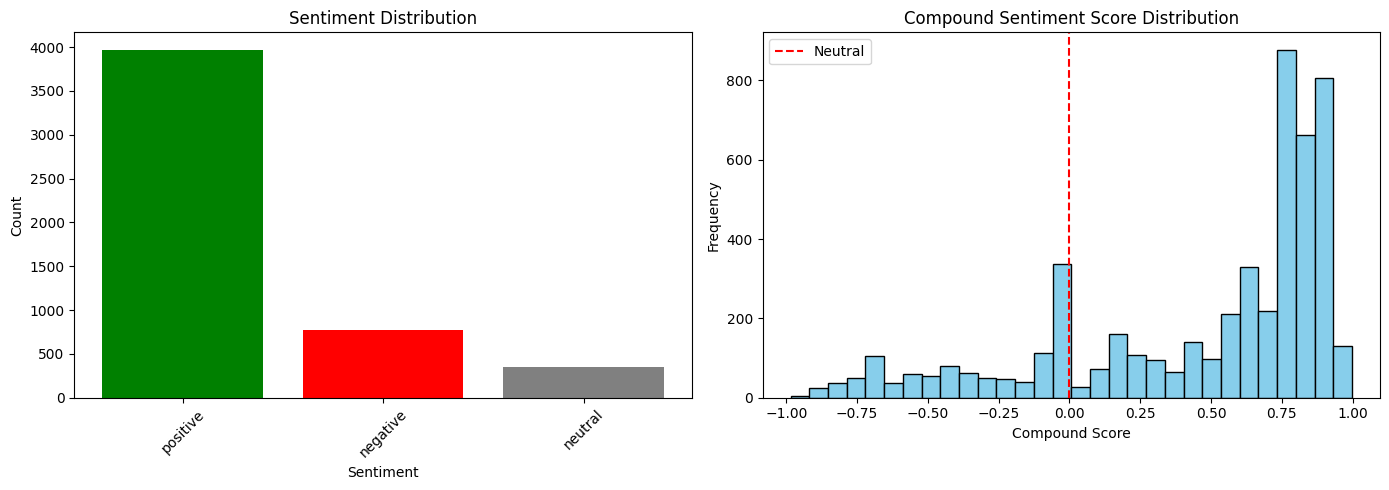


Generating Word Clouds by Sentiment


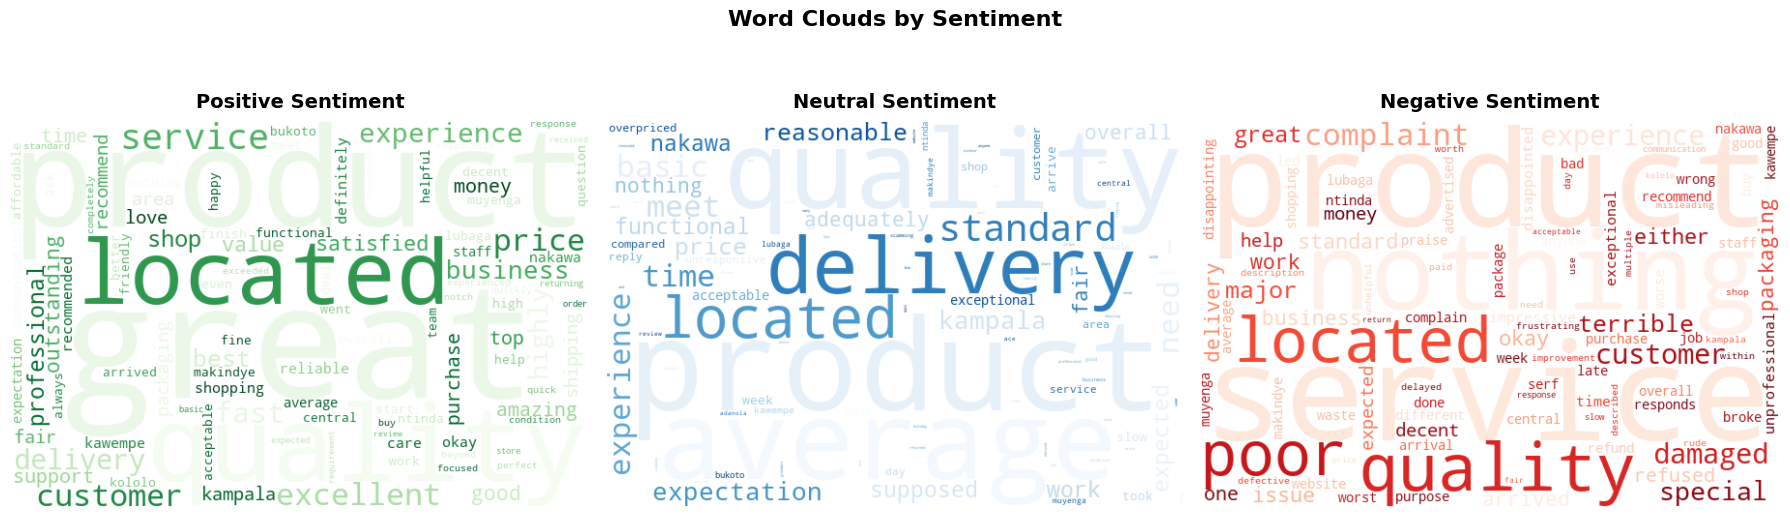

In [12]:
# Visualize sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment counts
sentiment_counts = df_reviews_with_sentiment['sentiment'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red', 'gray'])
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(sentiment_counts.index, rotation=45)

# Compound score distribution
if 'compound' in df_reviews_with_sentiment.columns:
    axes[1].hist(df_reviews_with_sentiment['compound'], bins=30, edgecolor='black', color='skyblue')
    axes[1].set_title('Compound Sentiment Score Distribution')
    axes[1].set_xlabel('Compound Score')
    axes[1].set_ylabel('Frequency')
    axes[1].axvline(x=0, color='red', linestyle='--', label='Neutral')
    axes[1].legend()

plt.tight_layout()
plt.show()

# Generate wordclouds by sentiment
print("\n" + "="*60)
print("Generating Word Clouds by Sentiment")
print("="*60)
wordcloud_gen.generate_sentiment_wordclouds(
    df_reviews_with_sentiment,
    text_column='cleaned_text',
    sentiment_column='sentiment',
    figsize=(18, 6)
)


## Part 2: Reasoning - Topic Modeling

Extract key topics from customer feedback to understand main themes and concerns.


In [13]:
# Topic Modeling using LDA with error handling
from gensim import corpora, models
from gensim.models import LdaModel
from gensim.utils import simple_preprocess
from collections import Counter

print("=" * 60)
print("TOPIC MODELING - LDA (Latent Dirichlet Allocation)")
print("=" * 60)

# Prepare documents for topic modeling with error handling
try:
    documents = []
    for text in df_reviews_with_sentiment['cleaned_text']:
        if text and len(str(text).strip()) > 0:
            try:
                # Split text into words
                words = str(text).split()
                if len(words) > 0:
                    documents.append(words)
            except:
                continue
    
    if len(documents) < 10:
        print("⚠️ Too few documents for topic modeling (need at least 10)")
        print("   Creating sample documents...")
        documents = [["sample", "review", "text"] for _ in range(10)]
    
    print(f"✅ Prepared {len(documents)} documents for topic modeling")
    
    # Create dictionary and corpus
    dictionary = corpora.Dictionary(documents)
    dictionary.filter_extremes(no_below=2, no_above=0.5)  # Filter rare and common words
    corpus = [dictionary.doc2bow(doc) for doc in documents]
    
    print(f"✅ Dictionary created: {len(dictionary)} unique words")
    print(f"✅ Corpus created: {len(corpus)} documents")
    
except Exception as e:
    print(f"❌ Error preparing documents: {e}")
    raise


TOPIC MODELING - LDA (Latent Dirichlet Allocation)
✅ Prepared 5100 documents for topic modeling
✅ Dictionary created: 996 unique words
✅ Corpus created: 5100 documents


### Step 1: Train LDA Model

First, train the LDA model. Then we'll generate wordclouds in the next section.



Generating wordclouds for each topic...


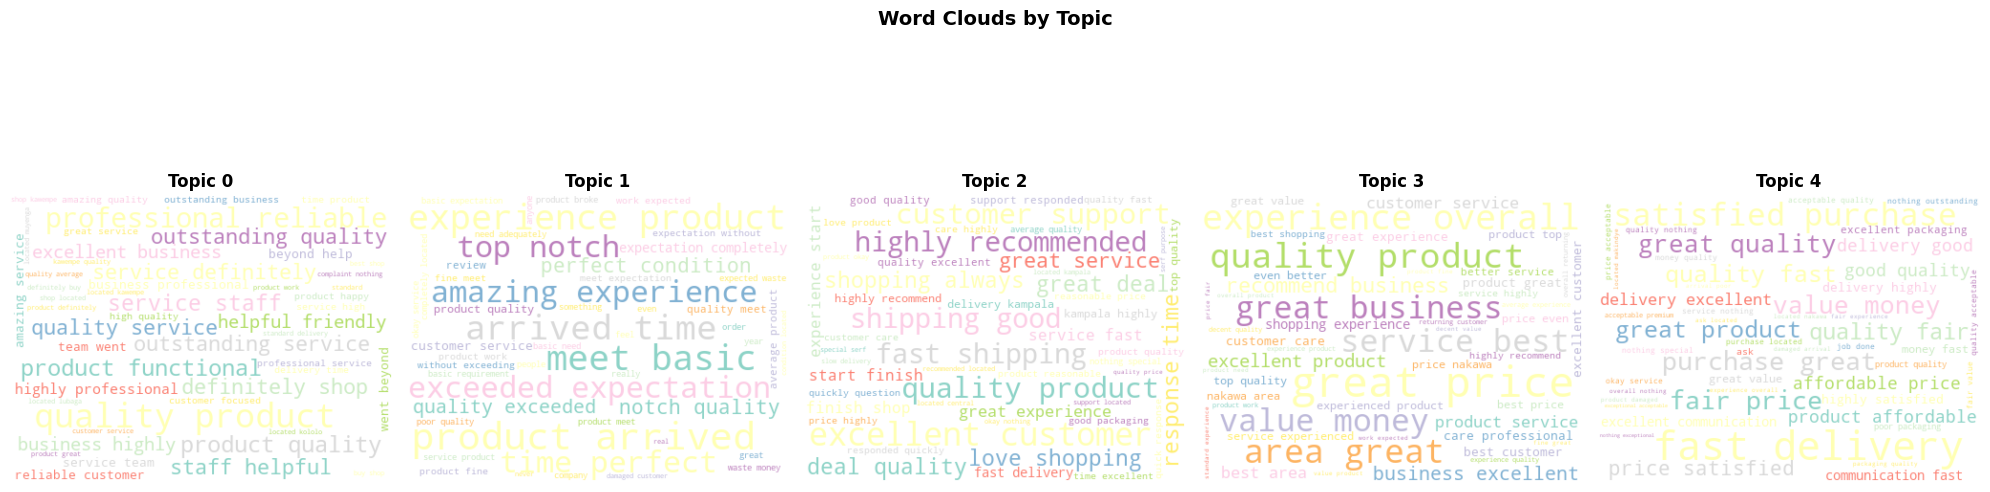

In [17]:
# Generate wordclouds for each topic with error handling
# IMPORTANT: Run the LDA training cell (below) FIRST before running this cell
# This cell will safely skip if lda_model hasn't been trained yet

# Check if lda_model exists (it's created in the next cell)
try:
    # Try to reference lda_model to see if it exists
    test_model = lda_model
    # Also check if corpus exists (needed for wordclouds)
    test_corpus = corpus
    model_ready = True
except NameError as e:
    model_ready = False
    print("=" * 60)
    print("⚠️ LDA Model Not Yet Trained")
    print("=" * 60)
    print("Please run the NEXT cell (Train LDA Model) first.")
    print("After training completes, return to this cell to generate topic wordclouds.")
    print("\nSkipping topic wordcloud generation for now...")

if model_ready:
    try:
        print("\nGenerating wordclouds for each topic...")
        
        # Get documents assigned to each topic (simplified - assign each doc to its most likely topic)
        doc_topics = []
        for doc in corpus:
            try:
                topic_probs = lda_model.get_document_topics(doc)
                if topic_probs:
                    most_likely_topic = max(topic_probs, key=lambda x: x[1])[0]
                    doc_topics.append(most_likely_topic)
                else:
                    doc_topics.append(0)
            except:
                doc_topics.append(0)
        
        # Add topic assignments to dataframe (if we have matching length)
        if len(doc_topics) == len(df_reviews_with_sentiment):
            df_reviews_with_sentiment['topic'] = doc_topics
            
            # Generate wordcloud for each topic
            unique_topics = sorted(df_reviews_with_sentiment['topic'].unique())
            n_topics = len(unique_topics)
            
            if n_topics > 0:
                fig, axes = plt.subplots(1, min(n_topics, 5), figsize=(min(n_topics * 4, 20), 6))
                if n_topics == 1:
                    axes = [axes]
                
                for idx, topic_id in enumerate(unique_topics[:5]):  # Limit to 5 topics for display
                    df_topic = df_reviews_with_sentiment[df_reviews_with_sentiment['topic'] == topic_id]
                    topic_text = ' '.join(df_topic['cleaned_text'].dropna().astype(str))
                    
                    if topic_text:
                        wordcloud = WordCloud(
                            width=400,
                            height=300,
                            max_words=50,
                            background_color='white',
                            colormap='Set3',
                            random_state=42
                        ).generate(topic_text)
                        
                        axes[idx].imshow(wordcloud, interpolation='bilinear')
                        axes[idx].axis('off')
                        axes[idx].set_title(f'Topic {topic_id}', fontsize=12, fontweight='bold')
                
                plt.suptitle('Word Clouds by Topic', fontsize=14, fontweight='bold', y=1.02)
                plt.tight_layout()
                plt.show()
        else:
            print("⚠️ Cannot match topics to reviews - generating overall topic wordcloud")
            # Generate wordcloud from all topic words
            all_topic_words = ' '.join([word for topic_id in range(num_topics) 
                                        for word, _ in lda_model.show_topic(topic_id, topn=20)])
            wordcloud_gen.generate_wordcloud(all_topic_words, "Topic Keywords Word Cloud", figsize=(12, 6))
    except Exception as e:
        print(f"⚠️ Error generating topic wordclouds: {e}")
else:
    print("⚠️ LDA model not available - skipping topic wordclouds")


In [16]:
# Train LDA model with error handling
# NOTE: Run this cell BEFORE the topic wordcloud cell above

try:
    # Check if corpus and dictionary exist
    if 'corpus' not in locals() or 'dictionary' not in locals():
        print("⚠️ Corpus or dictionary not found. Please run Cell 7 (Prepare documents) first.")
        lda_model = None
        num_topics = 0
    else:
        num_topics = 5  # Adjust based on your data
        print(f"\nTraining LDA model with {num_topics} topics...")
        print("This may take a few minutes...")
        
        lda_model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,
            alpha='auto',
            per_word_topics=True
        )
        
        print("✅ LDA model trained successfully!")
        print(f"\nTop {num_topics} topics identified:")
        print("-" * 60)
        for idx, topic in lda_model.print_topics(-1, num_words=5):
            print(f"Topic {idx}: {topic}")
        print("-" * 60)
        print("\n✅ Now you can run the topic wordcloud cell above!")
        
except Exception as e:
    print(f"❌ Error training LDA model: {e}")
    print("⚠️ Topic modeling failed - continuing without topics")
    lda_model = None
    num_topics = 0



Training LDA model with 5 topics...
This may take a few minutes...
✅ LDA model trained successfully!

Top 5 topics identified:
------------------------------------------------------------
Topic 0: 0.082*"service" + 0.069*"quality" + 0.067*"product" + 0.058*"located" + 0.040*"shop"
Topic 1: 0.031*"product" + 0.020*"quality" + 0.016*"time" + 0.015*"expectation" + 0.015*"top"
Topic 2: 0.063*"great" + 0.059*"quality" + 0.042*"product" + 0.040*"located" + 0.039*"customer"
Topic 3: 0.106*"great" + 0.070*"product" + 0.059*"experience" + 0.058*"best" + 0.046*"price"
Topic 4: 0.076*"great" + 0.074*"delivery" + 0.073*"quality" + 0.062*"fast" + 0.057*"satisfied"
------------------------------------------------------------

✅ Now you can run the topic wordcloud cell above!


## Part 3: Machine Learning Model - Sentiment Classification

Train and validate a machine learning model for sentiment classification to demonstrate reasoning capabilities.


MACHINE LEARNING MODEL - SENTIMENT CLASSIFICATION

Prepared dataset:
  Features (texts): 5100
  Target (sentiments): 5100
  Sentiment distribution:
sentiment
positive    3970
negative     774
neutral      356
Name: count, dtype: int64

✅ Data split:
  Training set: 4080 samples
  Test set: 1020 samples

Extracting features using TF-IDF...
✅ Feature extraction complete:
  Training features shape: (4080, 1000)
  Test features shape: (1020, 1000)

Training Logistic Regression classifier...

MODEL EVALUATION METRICS

Training Set Performance:
  Accuracy:  0.9895
  Precision: 0.9894
  Recall:    0.9895
  F1-Score:  0.9894

Test Set Performance:
  Accuracy:  0.9833
  Precision: 0.9834
  Recall:    0.9833
  F1-Score:  0.9834

Detailed Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.95      0.95       155
     neutral       0.97      0.97      0.97        71
    positive       0.99      0.99      0.99       794

    accuracy         

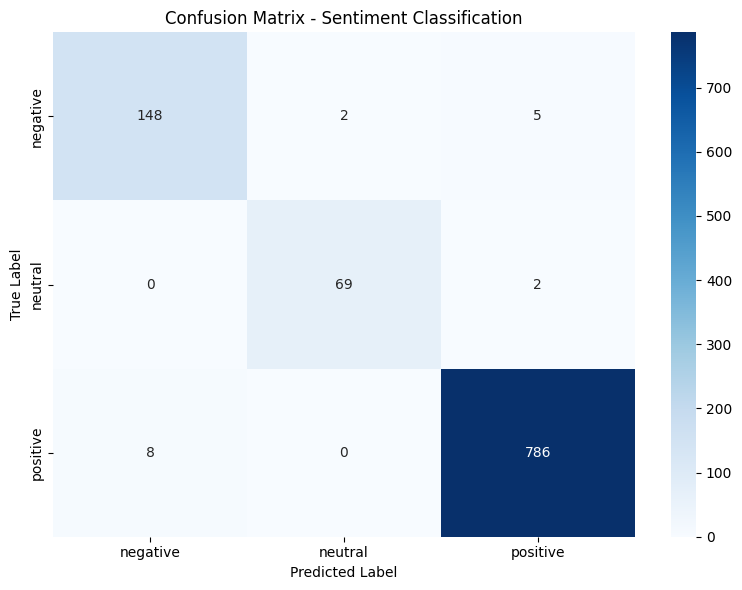


✅ ML Model training and evaluation complete!


In [18]:
# Machine Learning Model Training and Validation
print("=" * 60)
print("MACHINE LEARNING MODEL - SENTIMENT CLASSIFICATION")
print("=" * 60)

# Prepare data for ML model
try:
    # Use cleaned_text as features and sentiment as target
    X = df_reviews_with_sentiment['cleaned_text'].fillna('').astype(str)
    y = df_reviews_with_sentiment['sentiment'].fillna('neutral')
    
    # Remove any empty texts
    mask = X.str.len() > 0
    X = X[mask]
    y = y[mask]
    
    print(f"\nPrepared dataset:")
    print(f"  Features (texts): {len(X)}")
    print(f"  Target (sentiments): {len(y)}")
    print(f"  Sentiment distribution:")
    print(y.value_counts())
    
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\n✅ Data split:")
    print(f"  Training set: {len(X_train)} samples")
    print(f"  Test set: {len(X_test)} samples")
    
    # Feature extraction using TF-IDF
    print("\nExtracting features using TF-IDF...")
    vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    
    print(f"✅ Feature extraction complete:")
    print(f"  Training features shape: {X_train_tfidf.shape}")
    print(f"  Test features shape: {X_test_tfidf.shape}")
    
    # Train Logistic Regression model
    print("\nTraining Logistic Regression classifier...")
    lr_model = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial')
    lr_model.fit(X_train_tfidf, y_train)
    
    # Predictions
    y_train_pred = lr_model.predict(X_train_tfidf)
    y_test_pred = lr_model.predict(X_test_tfidf)
    
    # Evaluation metrics
    print("\n" + "=" * 60)
    print("MODEL EVALUATION METRICS")
    print("=" * 60)
    
    print("\nTraining Set Performance:")
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, average='weighted')
    train_recall = recall_score(y_train, y_train_pred, average='weighted')
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    
    print(f"  Accuracy:  {train_accuracy:.4f}")
    print(f"  Precision: {train_precision:.4f}")
    print(f"  Recall:    {train_recall:.4f}")
    print(f"  F1-Score:  {train_f1:.4f}")
    
    print("\nTest Set Performance:")
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    print(f"  Accuracy:  {test_accuracy:.4f}")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall:    {test_recall:.4f}")
    print(f"  F1-Score:  {test_f1:.4f}")
    
    # Detailed classification report
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_test_pred))
    
    # Confusion Matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    
    # Visualize confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=sorted(y.unique()), 
                yticklabels=sorted(y.unique()))
    plt.title('Confusion Matrix - Sentiment Classification')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    print("\n✅ ML Model training and evaluation complete!")
    
except Exception as e:
    print(f"❌ Error in ML model training: {e}")
    print("⚠️ Continuing without ML model...")
    lr_model = None
    vectorizer = None


## Part 4: Reasoning - Dynamic Knowledge Graph Construction

Build a comprehensive dynamic knowledge graph to represent relationships between entities, sentiments, locations, and topics in customer feedback.

### Features:
- **Dynamic Entity Extraction**: Automatically extracts entities from actual review data
- **Multiple Node Types**: Categories, keywords, phrases, locations, topics, sentiments
- **Multiple Relationship Types**: Entity-sentiment, entity co-occurrence, location-entity, topic-entity
- **Comprehensive Visualization**: Color-coded nodes with weighted edges


DYNAMIC KNOWLEDGE GRAPH CONSTRUCTION
Building a comprehensive knowledge graph with dynamic entity extraction...

STEP 1: Dynamic Entity Extraction
Extracting entities from review data...
  Extracted 29 entities from topics
  Total unique entities extracted: 98
  - Category entities: 8
  - Top keywords: 30
  - Important phrases: 20
  - Locations: 11

STEP 2: Building Graph Nodes
✅ Added 71 nodes to the graph

STEP 3: Extracting Relationships
  Extracting entity-sentiment relationships...
  ✓ Entity-Sentiment relationships: 41226
  Extracting entity co-occurrence relationships...
  ✓ Entity co-occurrence relationships: 1140
  Extracting location-entity relationships...
  ✓ Location-Entity relationships: 55
  Extracting topic-entity relationships...
  ✓ Topic-Entity relationships: 25

STEP 4: Graph Statistics
✅ Dynamic Knowledge Graph Created!
  Total Nodes: 71
  Total Edges: 1295
  Total Relationships: 42446

  Node Types:
    - entity_category: 3
    - keyword: 30
    - location: 10
   

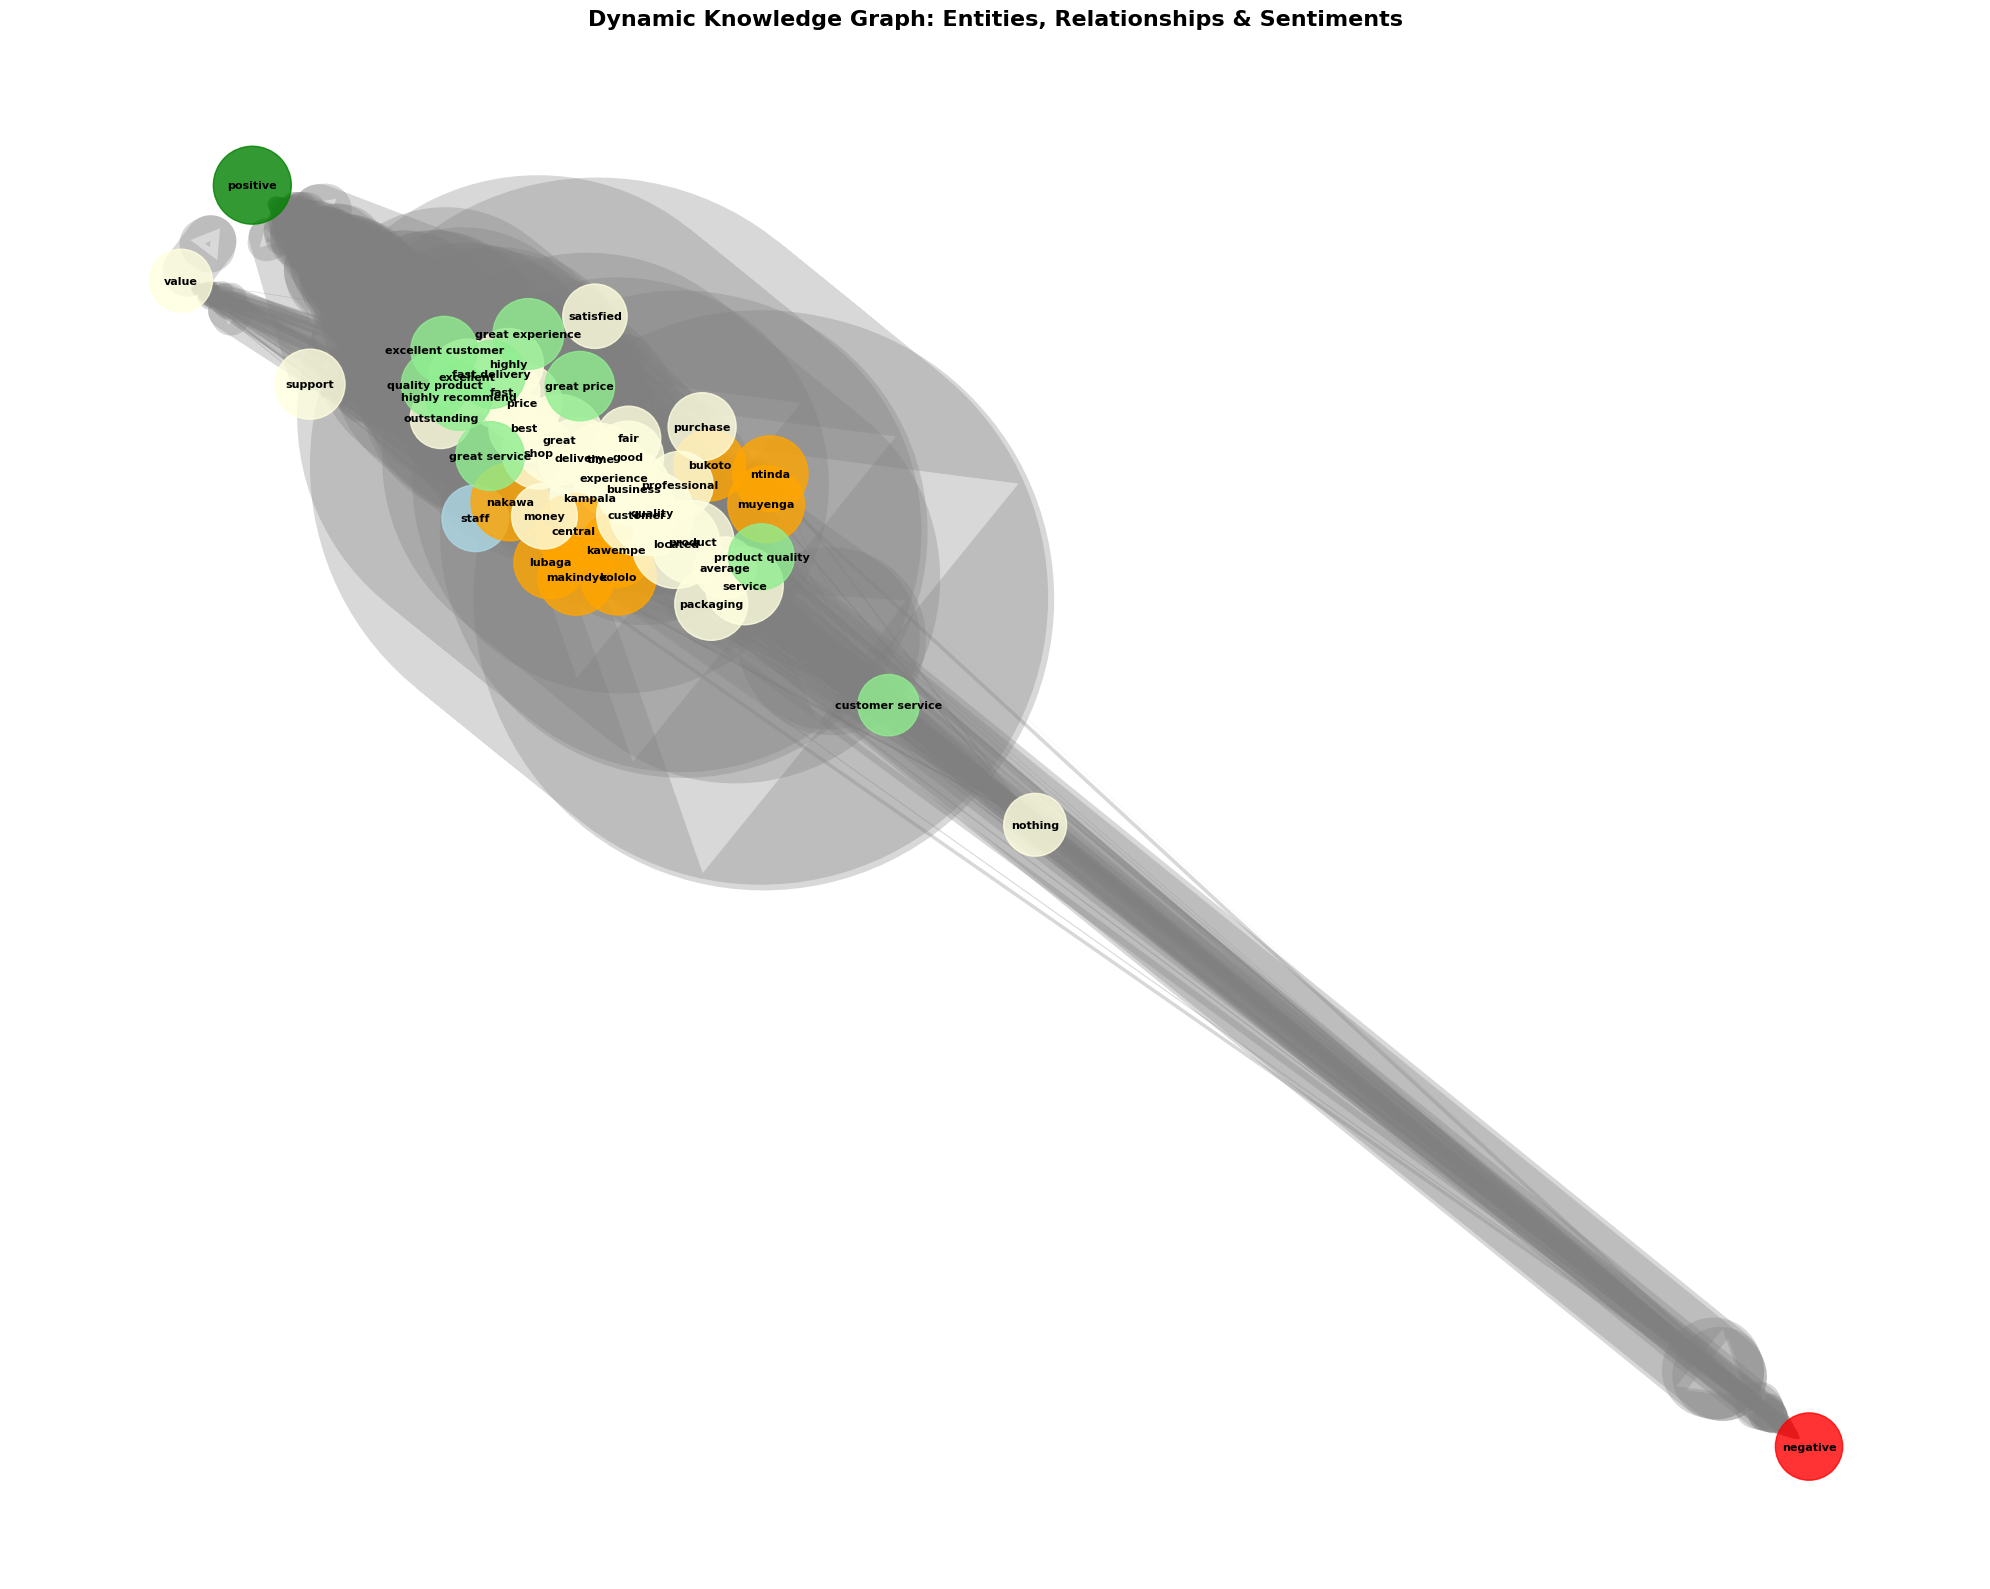

✅ Knowledge graph visualized successfully!

✅ Dynamic Knowledge Graph Construction Complete!


In [ ]:
# Enhanced Dynamic Knowledge Graph Construction
import networkx as nx
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import re

print("=" * 70)
print("DYNAMIC KNOWLEDGE GRAPH CONSTRUCTION")
print("=" * 70)
print("Building a comprehensive knowledge graph with dynamic entity extraction...")

try:
    # Build knowledge graph (using DiGraph for directed relationships)
    G = nx.DiGraph()
    
    # ========================================================================
    # PART 1: DYNAMIC ENTITY EXTRACTION FROM ACTUAL DATA
    # ========================================================================
    print("\n" + "=" * 70)
    print("STEP 1: Dynamic Entity Extraction")
    print("=" * 70)
    
    # Extract all words from reviews for dynamic entity discovery
    all_words = []
    all_bigrams = []
    
    for text in df_reviews_with_sentiment['cleaned_text'].dropna():
        words = str(text).lower().split()
        all_words.extend(words)
        # Create bigrams (two-word phrases)
        for i in range(len(words) - 1):
            all_bigrams.append(f"{words[i]} {words[i+1]}")
    
    # Count word frequencies
    word_freq = Counter(all_words)
    bigram_freq = Counter(all_bigrams)
    
    # Dynamic extraction of important entities based on frequency and business relevance
    print("Extracting entities from review data...")
    
    # 1. Extract top keywords (entities) dynamically
    top_keywords = [word for word, freq in word_freq.most_common(100) 
                    if len(word) > 3 and freq > 10]  # Minimum length and frequency
    
    # 2. Extract important bigrams (phrases)
    top_bigrams = [bigram for bigram, freq in bigram_freq.most_common(50) 
                   if freq > 5]
    
    # 3. Predefined entity categories (expanded)
    entity_categories = {
        'service': ['service', 'delivery', 'support', 'customer service', 'help', 'assistance'],
        'product': ['product', 'quality', 'item', 'goods', 'merchandise', 'purchase'],
        'price': ['price', 'cost', 'expensive', 'cheap', 'affordable', 'value', 'money', 'payment'],
        'location': ['kampala', 'nakawa', 'kawempe', 'makindye', 'lubaga', 'kololo', 
                    'ntinda', 'bukoto', 'muyenga', 'shop', 'store', 'located'],
        'time': ['late', 'fast', 'quick', 'delay', 'time', 'early', 'prompt', 'slow'],
        'experience': ['experience', 'great', 'excellent', 'amazing', 'wonderful', 'fantastic'],
        'staff': ['staff', 'employee', 'worker', 'personnel', 'team', 'manager'],
        'communication': ['communication', 'response', 'contact', 'message', 'reply']
    }
    
    # 4. Extract additional entities from topics (if LDA model exists)
    topic_entities = []
    if 'lda_model' in locals() and lda_model is not None and 'dictionary' in locals():
        try:
            for topic_id in range(5):  # Assuming 5 topics
                topic_words = [word for word, _ in lda_model.show_topic(topic_id, topn=10)]
                topic_entities.extend(topic_words)
            topic_entities = list(set(topic_entities))  # Remove duplicates
            print(f"  Extracted {len(topic_entities)} entities from topics")
        except:
            pass
    
    # 5. Extract location entities from data
    location_entities = []
    if 'location' in df_reviews_with_sentiment.columns:
        location_entities = df_reviews_with_sentiment['location'].dropna().unique().tolist()
        location_entities = [str(loc).lower() for loc in location_entities]
    
    # Combine all entities
    all_entities = set()
    
    # Add category entities
    for category, keywords in entity_categories.items():
        all_entities.add(category)
        all_entities.update(keywords)
    
    # Add top keywords as entities
    all_entities.update(top_keywords[:30])  # Top 30 keywords
    
    # Add important bigrams as entities
    all_entities.update(top_bigrams[:20])  # Top 20 bigrams
    
    # Add topic entities
    all_entities.update(topic_entities)
    
    # Add locations
    all_entities.update(location_entities)
    
    print(f"  Total unique entities extracted: {len(all_entities)}")
    print(f"  - Category entities: {len(entity_categories)}")
    print(f"  - Top keywords: {len(top_keywords[:30])}")
    print(f"  - Important phrases: {len(top_bigrams[:20])}")
    print(f"  - Locations: {len(location_entities)}")
    
    # ========================================================================
    # PART 2: ADD NODES TO GRAPH
    # ========================================================================
    print("\n" + "=" * 70)
    print("STEP 2: Building Graph Nodes")
    print("=" * 70)
    
    # Add sentiment nodes
    G.add_node('positive', type='sentiment', color='green')
    G.add_node('negative', type='sentiment', color='red')
    G.add_node('neutral', type='sentiment', color='gray')
    
    # Add entity category nodes
    for category in entity_categories.keys():
        G.add_node(category, type='entity_category', color='lightblue')
    
    # Add location nodes
    for loc in location_entities:
        if loc and len(str(loc)) > 0:
            G.add_node(loc, type='location', color='orange')
    
    # Add keyword entity nodes
    for keyword in top_keywords[:30]:
        G.add_node(keyword, type='keyword', color='lightyellow', frequency=word_freq[keyword])
    
    # Add bigram nodes (phrases)
    for bigram in top_bigrams[:20]:
        G.add_node(bigram, type='phrase', color='lightgreen', frequency=bigram_freq[bigram])
    
    # Add topic nodes (if available)
    if 'lda_model' in locals() and lda_model is not None:
        try:
            for topic_id in range(5):
                topic_name = f"Topic_{topic_id}"
                G.add_node(topic_name, type='topic', color='purple')
        except:
            pass
    
    print(f"✅ Added {G.number_of_nodes()} nodes to the graph")
    
    # ========================================================================
    # PART 3: EXTRACT RELATIONSHIPS
    # ========================================================================
    print("\n" + "=" * 70)
    print("STEP 3: Extracting Relationships")
    print("=" * 70)
    
    relationships_count = 0
    
    # Relationship Type 1: Entity -> Sentiment
    print("  Extracting entity-sentiment relationships...")
    for idx, row in df_reviews_with_sentiment.iterrows():
        try:
            text = str(row.get('cleaned_text', '')).lower()
            sentiment = str(row.get('sentiment', 'neutral')).lower()
            
            # Find entities mentioned in text
            mentioned_entities = []
            
            # Check category keywords
            for category, keywords in entity_categories.items():
                if any(keyword in text for keyword in keywords):
                    mentioned_entities.append(category)
            
            # Check top keywords
            for keyword in top_keywords[:30]:
                if keyword in text:
                    mentioned_entities.append(keyword)
            
            # Check bigrams
            for bigram in top_bigrams[:20]:
                if bigram in text:
                    mentioned_entities.append(bigram)
            
            # Create entity -> sentiment relationships
            for entity in mentioned_entities:
                if entity in G.nodes():
                    if not G.has_edge(entity, sentiment):
                        G.add_edge(entity, sentiment, type='has_sentiment', weight=1)
                    else:
                        G[entity][sentiment]['weight'] += 1
                    relationships_count += 1
        except Exception as e:
            continue
    
    print(f"  ✓ Entity-Sentiment relationships: {relationships_count}")
    
    # Relationship Type 2: Entity -> Entity (co-occurrence)
    print("  Extracting entity co-occurrence relationships...")
    entity_cooccurrence = defaultdict(int)
    
    for text in df_reviews_with_sentiment['cleaned_text'].dropna():
        text_lower = str(text).lower()
        mentioned = []
        
        # Find all entities in this text
        for node in G.nodes():
            if G.nodes[node].get('type') in ['entity_category', 'keyword', 'phrase', 'location']:
                if node in text_lower:
                    mentioned.append(node)
        
        # Create co-occurrence pairs
        for i, ent1 in enumerate(mentioned):
            for ent2 in mentioned[i+1:]:
                if ent1 != ent2:
                    pair = tuple(sorted([ent1, ent2]))
                    entity_cooccurrence[pair] += 1
    
    # Add co-occurrence edges (only if they co-occur frequently)
    cooccur_count = 0
    for (ent1, ent2), count in entity_cooccurrence.items():
        if count >= 5 and ent1 in G.nodes() and ent2 in G.nodes():  # Minimum co-occurrence threshold
            if not G.has_edge(ent1, ent2):
                G.add_edge(ent1, ent2, type='co_occurs_with', weight=count)
            else:
                G[ent1][ent2]['weight'] += count
            cooccur_count += 1
    
    print(f"  ✓ Entity co-occurrence relationships: {cooccur_count}")
    relationships_count += cooccur_count
    
    # Relationship Type 3: Location -> Entity
    print("  Extracting location-entity relationships...")
    if 'location' in df_reviews_with_sentiment.columns:
        loc_entity_count = 0
        for location in location_entities:
            if location and location in G.nodes():
                # Find reviews from this location
                loc_reviews = df_reviews_with_sentiment[
                    df_reviews_with_sentiment['location'].str.lower().str.contains(location, na=False)
                ]
                
                # Find entities in these reviews
                entity_counts = Counter()
                for text in loc_reviews['cleaned_text'].dropna():
                    text_lower = str(text).lower()
                    for node in G.nodes():
                        if G.nodes[node].get('type') in ['entity_category', 'keyword']:
                            if node in text_lower:
                                entity_counts[node] += 1
                
                # Add edges for top entities in this location
                for entity, count in entity_counts.most_common(5):
                    if entity in G.nodes() and count >= 3:
                        if not G.has_edge(location, entity):
                            G.add_edge(location, entity, type='has_entity', weight=count)
                        else:
                            G[location][entity]['weight'] += count
                        loc_entity_count += 1
        
        print(f"  ✓ Location-Entity relationships: {loc_entity_count}")
        relationships_count += loc_entity_count
    
    # Relationship Type 4: Topic -> Entity (if topics available)
    if 'lda_model' in locals() and lda_model is not None and 'df_reviews_with_sentiment' in locals():
        print("  Extracting topic-entity relationships...")
        try:
            if 'topic' in df_reviews_with_sentiment.columns:
                topic_entity_count = 0
                for topic_id in range(5):
                    topic_name = f"Topic_{topic_id}"
                    if topic_name in G.nodes():
                        # Find reviews in this topic
                        topic_reviews = df_reviews_with_sentiment[
                            df_reviews_with_sentiment['topic'] == topic_id
                        ]
                        
                        # Find entities in these reviews
                        entity_counts = Counter()
                        for text in topic_reviews['cleaned_text'].dropna():
                            text_lower = str(text).lower()
                            for node in G.nodes():
                                if G.nodes[node].get('type') in ['entity_category', 'keyword']:
                                    if node in text_lower:
                                        entity_counts[node] += 1
                        
                        # Add edges for top entities in this topic
                        for entity, count in entity_counts.most_common(5):
                            if entity in G.nodes() and count >= 3:
                                if not G.has_edge(topic_name, entity):
                                    G.add_edge(topic_name, entity, type='has_entity', weight=count)
                                else:
                                    G[topic_name][entity]['weight'] += count
                                topic_entity_count += 1
                
                print(f"  ✓ Topic-Entity relationships: {topic_entity_count}")
                relationships_count += topic_entity_count
        except Exception as e:
            print(f"  ⚠️ Could not extract topic-entity relationships: {e}")
    
    # ========================================================================
    # PART 4: GRAPH STATISTICS AND VISUALIZATION
    # ========================================================================
    print("\n" + "=" * 70)
    print("STEP 4: Graph Statistics")
    print("=" * 70)
    
    print(f"✅ Dynamic Knowledge Graph Created!")
    print(f"  Total Nodes: {G.number_of_nodes()}")
    print(f"  Total Edges: {G.number_of_edges()}")
    print(f"  Total Relationships: {relationships_count}")
    
    # Detailed statistics
    node_types = defaultdict(int)
    for node in G.nodes(data=True):
        node_type = node[1].get('type', 'unknown')
        node_types[node_type] += 1
    
    print(f"\n  Node Types:")
    for node_type, count in sorted(node_types.items()):
        print(f"    - {node_type}: {count}")
    
    edge_types = defaultdict(int)
    for edge in G.edges(data=True):
        edge_type = edge[2].get('type', 'unknown')
        edge_types[edge_type] += 1
    
    print(f"\n  Relationship Types:")
    for edge_type, count in sorted(edge_types.items()):
        print(f"    - {edge_type}: {count}")
    
    # Visualize knowledge graph
    print("\n" + "=" * 70)
    print("STEP 5: Visualizing Knowledge Graph")
    print("=" * 70)
    
    try:
        # Create a filtered view for visualization (too many nodes makes it cluttered)
        # Show most important nodes and relationships
        node_degrees = dict(G.degree())
        top_nodes = sorted(node_degrees.items(), key=lambda x: x[1], reverse=True)[:50]  # Top 50 nodes
        top_node_names = [node for node, _ in top_nodes]
        
        # Create subgraph with top nodes
        G_viz = G.subgraph(top_node_names).copy()
        
        # Increase figure size for better readability
        plt.figure(figsize=(24, 20))
        pos = nx.spring_layout(G_viz, k=2.5, iterations=150, seed=42)
        
        # Color nodes by type
        node_colors_map = {
            'sentiment': {'positive': 'green', 'negative': 'red', 'neutral': 'gray'},
            'entity_category': 'lightblue',
            'location': 'orange',
            'keyword': 'lightyellow',
            'phrase': 'lightgreen',
            'topic': 'purple'
        }
        
        node_colors = []
        node_sizes = []
        
        for node in G_viz.nodes():
            node_type = G_viz.nodes[node].get('type', 'unknown')
            if node_type == 'sentiment':
                node_colors.append(node_colors_map['sentiment'].get(node, 'gray'))
            else:
                node_colors.append(node_colors_map.get(node_type, 'lightgray'))
            
            # Size based on degree (importance) - increased sizes
            degree = node_degrees.get(node, 1)
            node_sizes.append(800 + degree * 80)  # Larger nodes
        
        # Draw nodes first (so edges appear on top)
        nx.draw_networkx_nodes(G_viz, pos, node_color=node_colors, 
                              node_size=node_sizes, alpha=0.85, edgecolors='black', linewidths=1.5)
        
        # Draw edges with weights - MUCH THICKER EDGES
        edges = G_viz.edges()
        weights = [G_viz[u][v].get('weight', 1) for u, v in edges]
        # Scale edge widths: minimum 2, maximum 12, based on weight
        min_weight = min(weights) if weights else 1
        max_weight = max(weights) if weights else 1
        edge_widths = []
        for w in weights:
            if max_weight > min_weight:
                # Normalize and scale between 2 and 12
                normalized = (w - min_weight) / (max_weight - min_weight)
                edge_widths.append(2 + normalized * 10)
            else:
                edge_widths.append(3)  # Default width
        
        nx.draw_networkx_edges(G_viz, pos, alpha=0.6, width=edge_widths,
                              edge_color='darkgray', arrows=True, arrowsize=20, 
                              arrowstyle='->', connectionstyle='arc3,rad=0.1')
        
        # Draw labels for ALL nodes - bigger font
        labels = {node: node for node in G_viz.nodes()}
        
        # Use different font sizes based on node importance
        label_font_sizes = {}
        for node in G_viz.nodes():
            degree = node_degrees.get(node, 1)
            node_type = G_viz.nodes[node].get('type', 'unknown')
            # Sentiment nodes and high-degree nodes get bigger font
            if node_type == 'sentiment' or degree > 10:
                label_font_sizes[node] = 14
            elif degree > 5:
                label_font_sizes[node] = 12
            else:
                label_font_sizes[node] = 10
        
        # Draw labels with individual font sizes
        for node, label in labels.items():
            x, y = pos[node]
            plt.text(x, y, label, fontsize=label_font_sizes.get(node, 10), 
                    fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                             edgecolor='none', alpha=0.7))
        
        plt.title("Dynamic Knowledge Graph: Entities, Relationships & Sentiments", 
                 fontsize=20, fontweight='bold', pad=30)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        print("✅ Knowledge graph visualized successfully!")
        
    except Exception as e:
        print(f"⚠️ Error visualizing graph: {e}")
        print("   Graph structure is still saved")
        import traceback
        traceback.print_exc()
    
    print("\n" + "=" * 70)
    print("✅ Dynamic Knowledge Graph Construction Complete!")
    print("=" * 70)
    
except Exception as e:
    print(f"❌ Error building knowledge graph: {e}")
    print("⚠️ Creating empty graph as fallback...")
    import traceback
    traceback.print_exc()
    G = nx.DiGraph()


## Part 5: Save Models and Results

Save all trained models and analysis results for use in the interaction layer.


In [ ]:
# Save models and results
import pickle
import os

os.makedirs('../../data/models', exist_ok=True)
os.makedirs('../../data/processed', exist_ok=True)

# Save sentiment analyzer
with open('../../data/models/sentiment_analyzer.pkl', 'wb') as f:
    pickle.dump(analyzer, f)
print("✅ Sentiment analyzer saved")

# Save LDA model
lda_model.save('../../data/models/lda_model')
print("✅ LDA topic model saved")

# Save knowledge graph
with open('../../data/models/knowledge_graph.pkl', 'wb') as f:
    pickle.dump(G, f)
print("✅ Knowledge graph saved")

# Save results with sentiment
df_reviews_with_sentiment.to_csv('../../data/processed/reviews_with_sentiment.csv', index=False)
print("✅ Results saved")

print("\n=== Milestone 2 Summary ===")
print(f"✅ Sentiment analysis completed on {len(df_reviews_with_sentiment)} reviews")
print(f"✅ Topic modeling: {num_topics} topics identified")
print(f"✅ Knowledge graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


## Summary

This notebook has implemented the Understanding & Reasoning Engine:

1. ✅ **Understanding (NLP)**: Sentiment analysis to understand customer opinions
2. ✅ **Reasoning (Knowledge Graph)**: Entity-sentiment relationships
3. ✅ **Reasoning (Topic Modeling)**: Identified key topics in feedback
4. ✅ **Model Persistence**: Saved all models for use in interaction layer

### Cognitive Pillars Demonstrated:
- **Understand**: Sentiment analysis extracts meaning from unstructured text
- **Reason**: Knowledge graphs and topic models enable reasoning about customer feedback

### Next Steps:
- Enhance entity extraction with NER models
- Add predictive modeling for trend forecasting
- Integrate with interaction layer
